In [1]:
import pandas as pd

df = pd.read_csv("Google_Stock_Price_Train.csv")


In [2]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [3]:
df.shape

(1258, 6)

In [4]:
training_set = df.iloc[:, 1:2].values

In [5]:
training_set[:5]

array([[325.25],
       [331.27],
       [329.83],
       [328.34],
       [322.04]])

***Next, we have to perform normalization of data using scaling. Our data will be scaled into a specific format. So we need the MinMaxScaler library as well***

In [6]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)
training_set_scaled

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]], shape=(1258, 1))

***Now, we create a data structure with 60 timesteps and one output as an Array of x_train and y_train***

In [7]:
import numpy as np

X_train = []
y_train = []
for i in range(60, 1258):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

***Here we have done reshaping of x_train data***

In [8]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

(1198, 60, 1)

***Now, the following libraries are required for building the RNN model and perform its operations. We have imported the Keras library and its packages.***

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

***Build the Model***

In [10]:
model = Sequential()

model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

C:\Users\muhammad.fayaz\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


***Compile the Model***

In [11]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [12]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2950
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.1262
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0781
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0606
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0482
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0340
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0262
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0236
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0219
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0190
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0168
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0145
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0158
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0126
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0123
Epoc

***Prediction on training data***

In [13]:
predicted_train = model.predict(X_train)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step  


***Transform to Actual***

In [14]:
# Inverse transform
predicted_train = sc.inverse_transform(predicted_train.reshape(-1, 1))
real_train = sc.inverse_transform(y_train.reshape(-1, 1))

***Visualization***

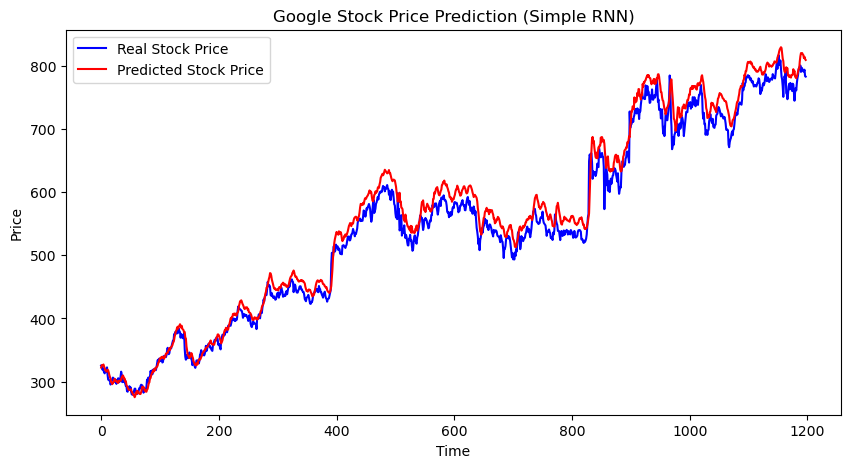

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(real_train, color='blue', label='Real Stock Price')
plt.plot(predicted_train, color='red', label='Predicted Stock Price')
plt.title('Google Stock Price Prediction (Simple RNN)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [18]:
rnn_layer = model.layers[0]   # first RNN layer
weights = rnn_layer.get_weights()

Wx = weights[0]   # input → hidden
Wh = weights[1]   # hidden → hidden
b  = weights[2]   # bias

print("Wx shape:", Wx.shape)
print("Wh shape:", Wh.shape)

Wx shape: (1, 50)
Wh shape: (50, 50)


array([[-0.25776652, -0.04899537,  0.04236919,  0.17894362, -0.168521  ,
         0.19459213, -0.04623399,  0.15847448, -0.22469987, -0.17495373,
         0.16343571, -0.18669018, -0.1103147 , -0.08807068,  0.20072399,
         0.13712767,  0.18579571, -0.20808792, -0.25661126, -0.07874388,
         0.08341742,  0.23083831,  0.2938124 , -0.17916875, -0.03528259,
         0.1863682 , -0.1444531 , -0.26802287, -0.08891209, -0.13950624,
         0.08703894,  0.28561515,  0.00272815, -0.18011923, -0.2827004 ,
        -0.24390292, -0.09839174,  0.08163124, -0.13941906, -0.07083502,
         0.1402707 ,  0.13283418,  0.28322324,  0.3215508 ,  0.19943759,
        -0.07514502,  0.10461012, -0.16135025,  0.2872736 ,  0.09662592]],
      dtype=float32)